# Task 08 - Artificial Neural Network (ANN)

Name: Malaika Noor

Objective:
Build and evaluate an Artificial Neural Network using TensorFlow/Keras and compare its performance with traditional machine learning models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

## Create Dataset

In [6]:
import pandas as pd

data = {
    "Clients":[10,15,20,25,30,35,40,45,50,55],
    "Team_Size":[2,3,4,5,6,7,8,9,10,11],
    "Duration":[1,2,3,4,5,6,7,8,9,10],
    "Project_Status":[
        "Completed","Completed","Completed",
        "In Progress","In Progress",
        "Completed","Completed",
        "In Progress","Completed","Completed"
    ]
}

df = pd.DataFrame(data)

print(df.head())

   Clients  Team_Size  Duration Project_Status
0       10          2         1      Completed
1       15          3         2      Completed
2       20          4         3      Completed
3       25          5         4    In Progress
4       30          6         5    In Progress


## Encode Target Variable

In [7]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["Project_Status"] = encoder.fit_transform(df["Project_Status"])

print(df.head())

   Clients  Team_Size  Duration  Project_Status
0       10          2         1               0
1       15          3         2               0
2       20          4         3               0
3       25          5         4               1
4       30          6         5               1


## Feature Selection

In [11]:
X = df[["Clients","Team_Size","Duration"]]

y = df["Project_Status"]



## Train Test Split

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

## TensorFlow Import

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

## TensorFlow Import

In [14]:
!pip install tensorflow

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

## Build ANN Model

In [17]:
model = Sequential()

In [18]:
model.add(Dense(16, activation="relu", input_shape=(3,)))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.add(Dense(8, activation="relu"))

In [20]:
model.add(Dense(1, activation="sigmoid"))

## Compile Model

In [21]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

## Train Model

In [22]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.3333 - loss: 0.7940 - val_accuracy: 0.5000 - val_loss: 0.7493
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.3333 - loss: 0.7662 - val_accuracy: 0.5000 - val_loss: 0.7268
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.3333 - loss: 0.7422 - val_accuracy: 0.5000 - val_loss: 0.7076
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.3333 - loss: 0.7227 - val_accuracy: 0.5000 - val_loss: 0.6963
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.3333 - loss: 0.7105 - val_accuracy: 0.5000 - val_loss: 0.6957
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.1667 - loss: 0.7009 - val_accuracy: 0.5000 - val_loss: 0.6935
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.5000 - loss: 0.6913 - val_accuracy: 0.5000 - val_loss: 0.6882
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.6667 - loss: 0.6833 - val_accuracy: 0.5000 - val_loss: 0.6840
Ep

## Accuracy Curve

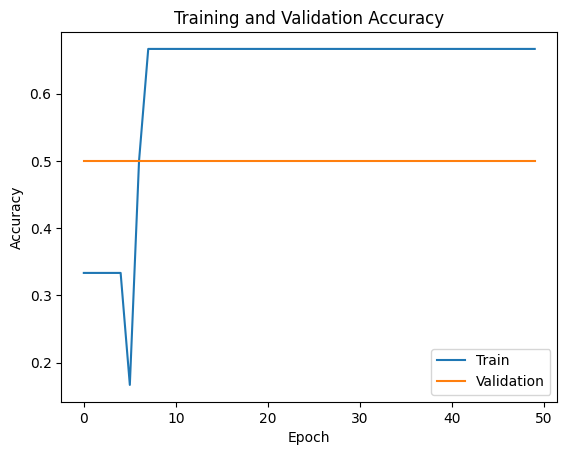

In [23]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

## Loss Curve

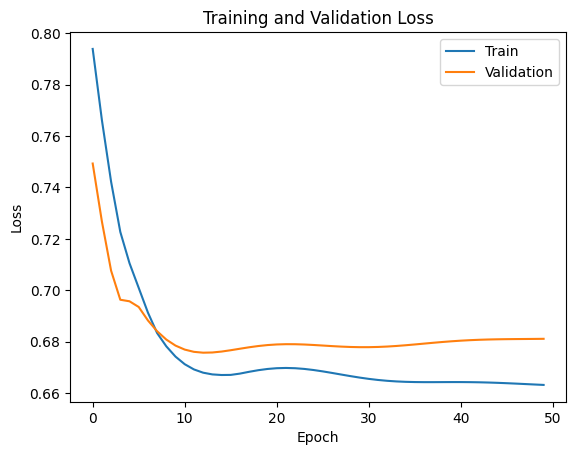

In [24]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train","Validation"])

plt.show()

## Model Evaluation

In [25]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 1.0000 - loss: 0.5212
Accuracy: 1.0


## Predictions

In [26]:
predictions = model.predict(X_test)

print(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
[[0.37032944]
 [0.44002438]]


## Comparison with Traditional ML Models

Traditional machine learning models such as Logistic Regression, Decision Tree, and Random Forest were developed in Task 05.

The ANN model uses multiple hidden layers and can learn complex patterns from data.

Random Forest performed well on small datasets, while ANN is more effective for larger and more complex datasets.

Both approaches can be used for project status prediction depending on dataset size and complexity.